In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report

# Load dataset
df = pd.read_csv("q1_heart_disease.csv")

# Display shape
print("Shape of dataset:", df.shape)

# Display data types
print("\nData Types:\n", df.dtypes)

# Display missing values
print("\nMissing Values:\n", df.isnull().sum())

# Show first 5 rows
print("\nFirst 5 rows:\n")
df.head()

Shape of dataset: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows:



,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


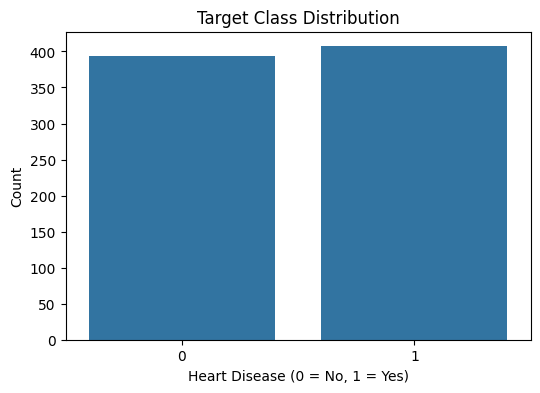

In [9]:
##2. Exploratory Data Analysis
### Target Class Distribution

plt.figure(figsize=(6,4))
sns.countplot(x="heart_disease", data=df)
plt.title("Target Class Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

### Interpretation of Target Class Distribution
- The target classes are almost balanced, with slightly more patients having heart disease than not having the heart disaese.
- This is good because model training will not be heavily biased toward one class.


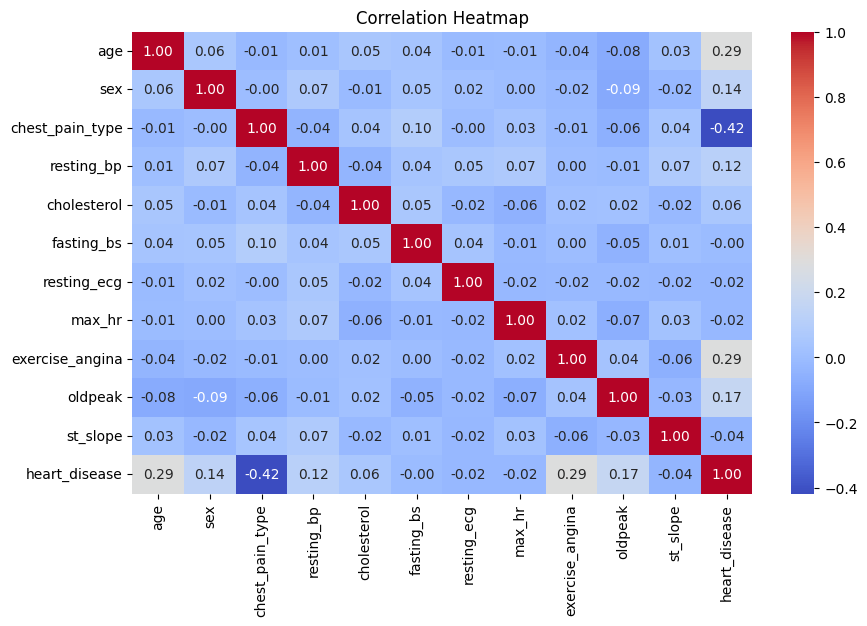

In [10]:
# Create a copy for correlation plotting
corr_df = df.copy()

# Convert object columns to category codes only for heatmap visualization
for col in corr_df.select_dtypes(include="object").columns:
    corr_df[col] = corr_df[col].astype("category").cat.codes

plt.figure(figsize=(10,6))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Interpretation of Correlation Heatmap
- The heatmap shows the correlation between numerical features in the dataset.
- Some features such as `oldpeak`, `exercise_angina`, `st_slope`, and `max_hr` appear to have noticeable relationships with the target.
- This suggests that these features may be important for prediction.

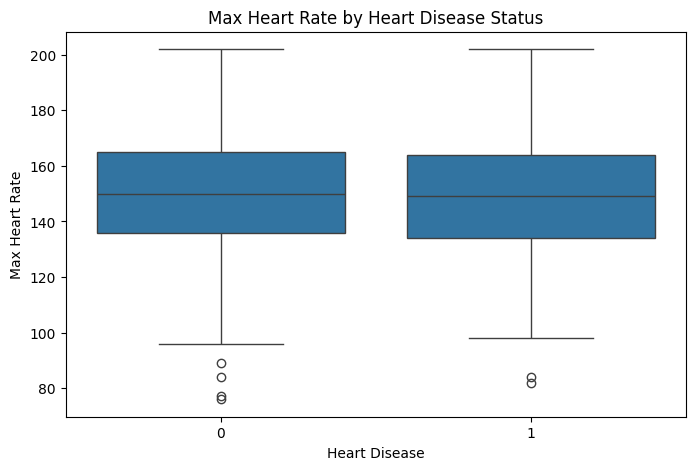

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(x="heart_disease", y="max_hr", data=df)
plt.title("Max Heart Rate by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Max Heart Rate")
plt.show()

### Interpretation
- Patients without heart disease tend to have a higher maximum heart rate compared to those with heart disease.
- This indicates that `max_hr` may help separate the two classes.
- Outliers can also be observed, which may require preprocessing.


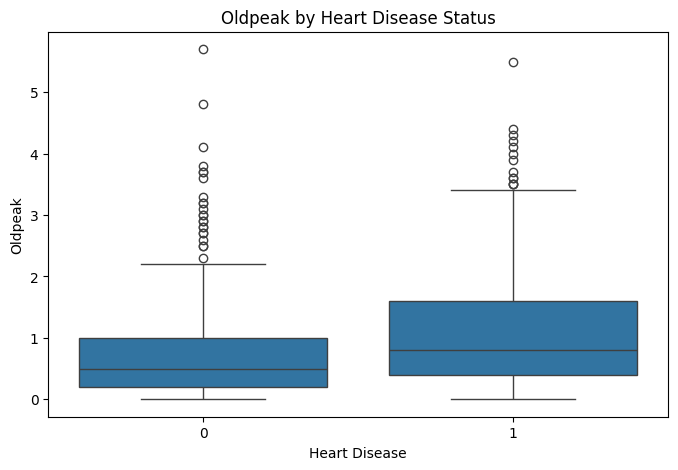

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x="heart_disease", y="oldpeak", data=df)
plt.title("Oldpeak by Heart Disease Status")
plt.xlabel("Heart Disease")
plt.ylabel("Oldpeak")
plt.show()

### Interpretation
- Patients with heart disease generally show higher `oldpeak` values.
- This suggests that greater ST depression may be associated with heart disease presence.

In [14]:
## 3. Data Preprocessing

# Define target and features

X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

# Preprocessing for numerical data
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Fit and transform training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)



Categorical features: ['chest_pain_type', 'resting_ecg', 'st_slope']
Numerical features: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']
X_train shape: (640, 11)
X_test shape: (160, 11)
y_train shape: (640,)
y_test shape: (160,)
Processed X_train shape: (640, 18)
Processed X_test shape: (160, 18)


### Missing Value Handling Strategy
We are using **median imputation** for numerical columns because:
- only a small number of values are missing,
- median is robust to outliers,
- dropping rows would unnecessarily reduce the dataset size.

Categorical columns are imputed with the **most frequent value**.

Then:
- categorical variables are one-hot encoded,
- numerical variables are scaled using `StandardScaler`,
- the dataset is split using `train_test_split` with `stratify=y` and `random_state=42`.

In [15]:
## Decision tree model training

dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [16]:
## Random Forest Model training

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [17]:
## Gradient Boosting model training

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

gb_model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")


Gradient Boosting model trained successfully.


## Model Training

The following three classification models were trained separately using scikit-learn:

- Decision Tree Classifier
- Random Forest Classifier
- Gradient Boosting Classifier

Each model was built using a pipeline that first applies preprocessing and then trains the classifier.  
The parameter `random_state=42` was fixed for all models to ensure reproducibility of results.

In [18]:
##Confusion matrix, Precision, Recall, and F1-score on the test set of Decision tree

dt_pred = dt_model.predict(X_test)

print("Decision Tree - Confusion Matrix")
print(confusion_matrix(y_test, dt_pred))

print("\nDecision Tree Metrics")
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1-score:", f1_score(y_test, dt_pred))

Decision Tree - Confusion Matrix
[[56 23]
 [22 59]]

Decision Tree Metrics
Precision: 0.7195121951219512
Recall: 0.7283950617283951
F1-score: 0.7239263803680982


In [19]:
##Confusion matrix, Precision, Recall, and F1-score on the test set of Random Forest

rf_pred = rf_model.predict(X_test)

print("Random Forest - Confusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nRandom Forest Metrics")
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1-score:", f1_score(y_test, rf_pred))

Random Forest - Confusion Matrix
[[60 19]
 [15 66]]

Random Forest Metrics
Precision: 0.7764705882352941
Recall: 0.8148148148148148
F1-score: 0.7951807228915663


In [20]:
##Confusion matrix, Precision, Recall, and F1-score on the test set of Gradient Boosting
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting - Confusion Matrix")
print(confusion_matrix(y_test, gb_pred))

print("\nGradient Boosting Metrics")
print("Precision:", precision_score(y_test, gb_pred))
print("Recall:", recall_score(y_test, gb_pred))
print("F1-score:", f1_score(y_test, gb_pred))


Gradient Boosting - Confusion Matrix
[[61 18]
 [18 63]]

Gradient Boosting Metrics
Precision: 0.7777777777777778
Recall: 0.7777777777777778
F1-score: 0.7777777777777778


## Model Evaluation

All three models were evaluated using confusion matrix, precision, recall, and F1-score on the test set.

Among the three models, **Random Forest performed the best** because it gave the highest **F1-score**, along with strong precision and recall.

This model is preferred because:
- **Precision** shows how many predicted positive cases were actually correct.
- **Recall** shows how many actual positive cases were correctly identified.
- **F1-score** gives a balance between precision and recall.

Since heart disease prediction is a classification problem where both false positives and false negatives matter, **F1-score is a better measure than accuracy alone**. Therefore, the model with the best balance of precision and recall should be selected as the best model.

In [21]:
##Tuning Random Forest with GridSearchCV

param_grid = {
    "classifier__n_estimators": [50, 100, 200]
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best Cross-Validation F1-score:", rf_grid.best_score_)

Best Parameters: {'classifier__n_estimators': 200}
Best Cross-Validation F1-score: 0.8105065680466923


In [22]:
## Evaluating Tuned Model on Test Set
best_rf_model = rf_grid.best_estimator_

tuned_rf_pred = best_rf_model.predict(X_test)

print("Tuned Random Forest - Confusion Matrix")
print(confusion_matrix(y_test, tuned_rf_pred))

print("\nTuned Random Forest Metrics")
print("Precision:", precision_score(y_test, tuned_rf_pred))
print("Recall:", recall_score(y_test, tuned_rf_pred))
print("F1-score:", f1_score(y_test, tuned_rf_pred))

Tuned Random Forest - Confusion Matrix
[[60 19]
 [15 66]]

Tuned Random Forest Metrics
Precision: 0.7764705882352941
Recall: 0.8148148148148148
F1-score: 0.7951807228915663


In [23]:
## Comparing Tuned vs Untuned Model
baseline_precision = precision_score(y_test, rf_pred)
baseline_recall = recall_score(y_test, rf_pred)
baseline_f1 = f1_score(y_test, rf_pred)

tuned_precision = precision_score(y_test, tuned_rf_pred)
tuned_recall = recall_score(y_test, tuned_rf_pred)
tuned_f1 = f1_score(y_test, tuned_rf_pred)

print("Untuned Random Forest")
print("Precision:", baseline_precision)
print("Recall:", baseline_recall)
print("F1-score:", baseline_f1)

print("\nTuned Random Forest")
print("Precision:", tuned_precision)
print("Recall:", tuned_recall)
print("F1-score:", tuned_f1)

Untuned Random Forest
Precision: 0.7764705882352941
Recall: 0.8148148148148148
F1-score: 0.7951807228915663

Tuned Random Forest
Precision: 0.7764705882352941
Recall: 0.8148148148148148
F1-score: 0.7951807228915663


## Hyperparameter Tuning Result

Using GridSearchCV, the best value found for `n_estimators` was reported as **200**.

The tuned Random Forest model was then tested on the test set and compared with the untuned baseline model.

The best cross-validation F1-score obtained during tuning was **0.8105**.

When the tuned model was evaluated on the test set, its performance was:

- **Precision = 0.7765**
- **Recall = 0.8148**
- **F1-score = 0.7952**

The untuned baseline Random Forest model had exactly the same test performance:

- **Precision = 0.7765**
- **Recall = 0.8148**
- **F1-score = 0.7952**

### Conclusion
Although GridSearchCV selected **200 trees** as the best parameter setting, the tuned model did **not improve** test-set performance compared to the untuned baseline model.  
This means the original Random Forest model was already performing well, and increasing the number of trees did not lead to better generalization on the test data.
